# Week 4 Day 5 — Save PCA Outputs

Persists two files that Week 6 (hedging) will load directly:

| file | contents | used for |
|------|----------|----------|
| `pca_loadings.parquet` | sign-corrected loading vectors + variance ratios | factor-exposure calculation: `KRD @ PC_loading` |
| `factor_scores.parquet` | daily bp scores for every PC | regime labelling in Week 7 |

Nothing new is computed here — this is purely a persistence step.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from termstructure.pca.decomposition import save_pca_outputs
from termstructure.pca.panel import DEFAULT_MATURITIES

## 1. Save outputs

In [2]:
info = save_pca_outputs()

print(f"Components saved : {info['n_components']}")
print(f"Score rows saved : {info['n_score_rows']}")
print(f"PC1+PC2+PC3 var  : {info['var_3pc']:.1%}")
print(f"Loadings path    : {info['loadings_path']}")
print(f"Scores path      : {info['scores_path']}")

Components saved : 8
Score rows saved : 10093
PC1+PC2+PC3 var  : 97.8%
Loadings path    : C:\Users\aarna\Documents\termstructure\data\processed\pca_loadings.parquet
Scores path      : C:\Users\aarna\Documents\termstructure\data\processed\factor_scores.parquet


## 2. Loadings parquet

One row per PC. The `y_*` columns are the sign-corrected loading weights —
Week 6 will dot-product these with a bond's key-rate durations to get its
factor exposure.

In [3]:
loadings = pd.read_parquet('../data/processed/pca_loadings.parquet')
loadings.set_index('pc', inplace=True)
print(f'Shape: {loadings.shape}  (n_components × (var_ratio + n_maturities))')
loadings.round(4)

Shape: (8, 9)  (n_components × (var_ratio + n_maturities))


,var_ratio,y_1,y_2,y_3,y_5,y_7,y_10,y_20,y_30
pc,,,,,,,,,
1,0.8375,0.2446,0.3345,0.3758,0.4040,0.4045,0.3895,0.3361,0.3091
2,0.1085,-0.4015,-0.4044,-0.3247,-0.1280,0.0320,0.1886,0.4137,0.5880
3,0.0322,0.3686,0.2132,0.0662,-0.1361,-0.2808,-0.4238,-0.2081,0.7029
4,0.0131,0.4896,0.1189,-0.1662,-0.3926,-0.2918,0.0825,0.6485,-0.2279
5,0.0073,0.5443,-0.2699,-0.4637,-0.0646,0.3114,0.3821,-0.4061,0.0621
6,0.0012,-0.3032,0.5590,-0.0178,-0.5026,-0.0969,0.5080,-0.2610,0.0842
7,0.0001,0.1212,-0.4997,0.6021,-0.0901,-0.4340,0.3970,-0.1315,0.0409
8,0.0000,-0.0229,0.1734,-0.3787,0.6187,-0.6138,0.2542,-0.0418,0.0105


## 3. Loading heatmap — quick sanity check

PC1 should be flat, PC2 monotonic, PC3 U-shaped.
Rows 4–8 should look like noise.

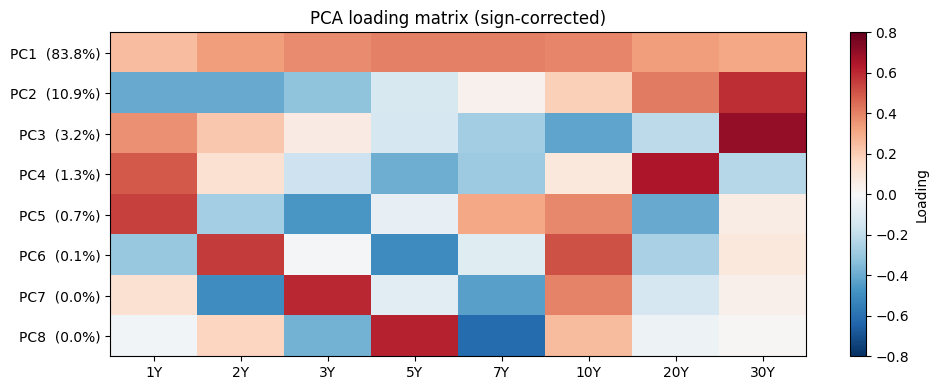

In [4]:
mat_cols = [c for c in loadings.columns if c.startswith('y_')]
L = loadings[mat_cols].to_numpy()

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(L, aspect='auto', cmap='RdBu_r', vmin=-0.8, vmax=0.8)
plt.colorbar(im, ax=ax, label='Loading')
ax.set_xticks(range(len(DEFAULT_MATURITIES)))
ax.set_xticklabels([f'{m}Y' for m in DEFAULT_MATURITIES])
ax.set_yticks(range(len(L)))
ax.set_yticklabels([f'PC{i+1}  ({loadings["var_ratio"].iloc[i]:.1%})' for i in range(len(L))])
ax.set_title('PCA loading matrix (sign-corrected)')
plt.tight_layout()
plt.savefig('data/week4_day5_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Factor scores parquet

In [5]:
scores = pd.read_parquet('../data/processed/factor_scores.parquet')
scores['date'] = pd.to_datetime(scores['date'])
scores = scores.set_index('date')

print(f'Shape: {scores.shape}   {scores.index[0].date()} -> {scores.index[-1].date()}')
print(f'Columns: {list(scores.columns)}')
print()
print('Daily score stats (bp):')
score_cols = [c for c in scores.columns if c.startswith('score_')]
scores[score_cols[:3]].describe().round(2)

Shape: (10093, 8)   1985-11-26 -> 2026-05-01
Columns: ['score_1', 'score_2', 'score_3', 'score_4', 'score_5', 'score_6', 'score_7', 'score_8']

Daily score stats (bp):


,score_1,score_2,score_3
count,10093.00,10093.00,10093.00
mean,-0.14,-0.01,-0.01
std,14.88,5.35,2.92
min,-172.45,-39.04,-39.12
25%,-8.39,-2.82,-1.12
50%,-0.24,-0.09,0.04
75%,8.03,2.75,1.17
max,92.14,57.76,28.90


## 5. Verify: loadings are orthonormal

`L @ L.T` should be the identity matrix. Diagonal = 1 (each row has unit norm);
off-diagonal = 0 (rows are orthogonal). This is the definition of PCA components.

In [6]:
gram = L @ L.T
print('L @ L.T (should be identity):')
print(gram.round(6))

is_identity = np.allclose(gram, np.eye(len(L)), atol=1e-6)
print(f'\nOrthonormal: {"PASS" if is_identity else "FAIL"}')

L @ L.T (should be identity):
[[ 1.  0. -0.  0. -0.  0.  0. -0.]
 [ 0.  1.  0.  0.  0.  0. -0.  0.]
 [-0.  0.  1. -0. -0.  0.  0.  0.]
 [ 0.  0. -0.  1. -0. -0. -0. -0.]
 [-0.  0. -0. -0.  1. -0.  0.  0.]
 [ 0.  0.  0. -0. -0.  1. -0. -0.]
 [ 0. -0.  0. -0.  0. -0.  1. -0.]
 [-0.  0.  0. -0.  0. -0. -0.  1.]]

Orthonormal: PASS
